<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/business_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.download('Customer_Segments_Output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==========================================
# STEP 2: LOAD AND PREPARE THE DATA
# ==========================================
# Load the cleaned dataset
df = pd.read_csv('cleaned_ecommerce_data_2026.csv')

# Make sure the order_date is a proper datetime object
df['order_date'] = pd.to_datetime(df['order_date'])

# Find the "current date" (the day after the very last order in our dataset)
# We need this to calculate how many days it has been since a customer last bought something.
current_date = df['order_date'].max() + pd.Timedelta(days=1)

# ==========================================
# STEP 3: CALCULATE R.F.M. FOR EACH CUSTOMER
# ==========================================
# Group the data by Customer_ID to calculate Recency, Frequency, and Monetary values
rfm_data = df.groupby('customer_id').agg({
    'order_date': lambda date: (current_date - date.max()).days,  # Recency: Days since last order
    'order_id': 'count',                                          # Frequency: Total number of orders
    'total_amount': 'sum'                                         # Monetary: Total money spent
}).reset_index()

# Rename the columns so they are easy to read
rfm_data.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print("--- Step 3 Completed: RFM Data Created ---")
print(rfm_data.head())


# ==========================================
# STEP 4: SCALE THE DATA (Crucial for Machine Learning)
# ==========================================
# Machine learning algorithms get confused if numbers are on different scales
# (e.g., frequency is '5' but monetary is '50000'). We shrink them to a similar scale.
scaler = StandardScaler()

# We only scale the math columns, not the Customer_ID!
columns_to_scale = ['recency', 'frequency', 'monetary']
scaled_numbers = scaler.fit_transform(rfm_data[columns_to_scale])


# ==========================================
# STEP 5: APPLY K-MEANS CLUSTERING (The Magic)
# ==========================================
# We are telling the algorithm: "Please split my customers into 4 distinct groups"
kmeans_model = KMeans(n_clusters=4, random_state=42)

# The model learns the patterns and assigns a "Cluster Number" (0, 1, 2, or 3) to each customer
rfm_data['customer_segment'] = kmeans_model.fit_predict(scaled_numbers)


# ==========================================
# STEP 6: NAME THE SEGMENTS & SAVE
# ==========================================
# Let's see the average spending and frequency for each group to understand who they are
segment_summary = rfm_data.groupby('customer_segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_id': 'count' # This counts how many customers are in each group
}).round(1)

print("\n--- Here are your 4 Customer Segments! ---")
print(segment_summary)

# Save the final results to a new Excel/CSV file so you can give it to the Marketing Team!
rfm_data.to_csv('Customer_Segments_Output.csv', index=False)
print("\nSuccess! Saved customer segments to 'Customer_Segments_Output.csv'")

--- Step 3 Completed: RFM Data Created ---
  customer_id  recency  frequency  monetary
0        C001        6        102    810827
1        C002        1        116   3382739
2        C003        1         83    363176
3        C004        3         94   2094790
4        C005        1         88    501637

--- Here are your 4 Customer Segments! ---
                  recency  frequency   monetary  customer_id
customer_segment                                            
0                     9.2      113.8   874784.4            5
1                     3.0       99.4  2217695.0            9
2                     2.7       90.2   575933.2           16
3                     2.8      104.6   756206.1           20

Success! Saved customer segments to 'Customer_Segments_Output.csv'


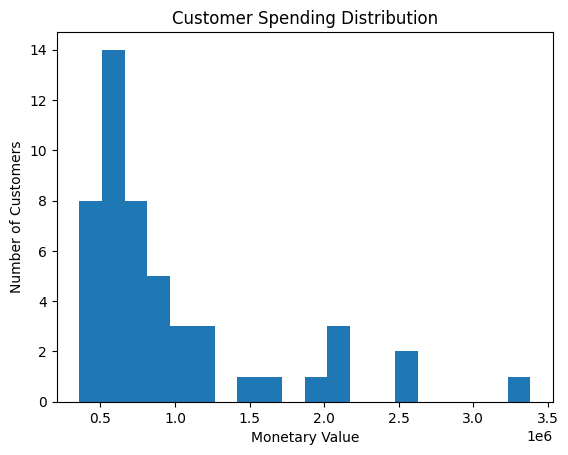

In [ ]:
import matplotlib.pyplot as plt

plt.hist(rfm_data['monetary'], bins=20)
plt.title("Customer Spending Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Number of Customers")
plt.savefig('monetary_distribution.png')
plt.show()

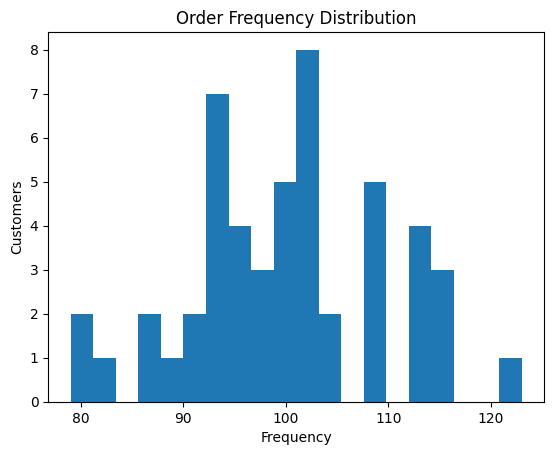

In [ ]:
import matplotlib.pyplot as plt

plt.hist(rfm_data['frequency'], bins=20)
plt.title("Order Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Customers")
plt.savefig('frequency_distribution.png')
plt.show()

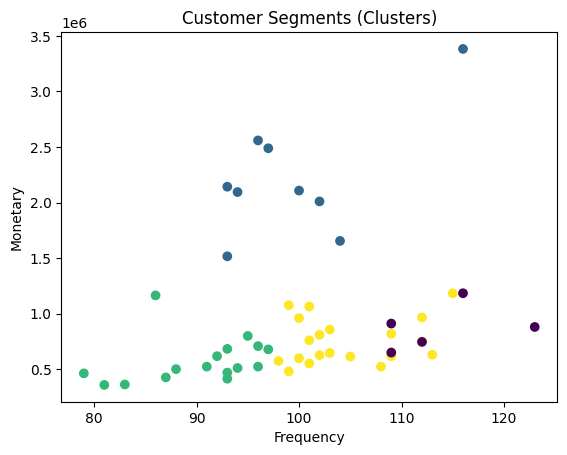

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(rfm_data['frequency'], rfm_data['monetary'],
            c=rfm_data['customer_segment'])

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments (Clusters)")
plt.savefig('rfm_scatter_segments.png')
plt.show()

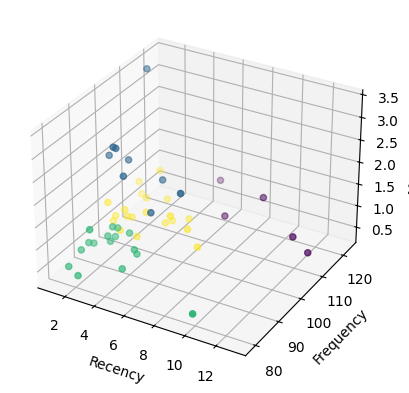

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm_data['recency'],
           rfm_data['frequency'],
           rfm_data['monetary'],
           c=rfm_data['customer_segment'])

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.savefig('rfm_3d_scatter.png')
plt.show()

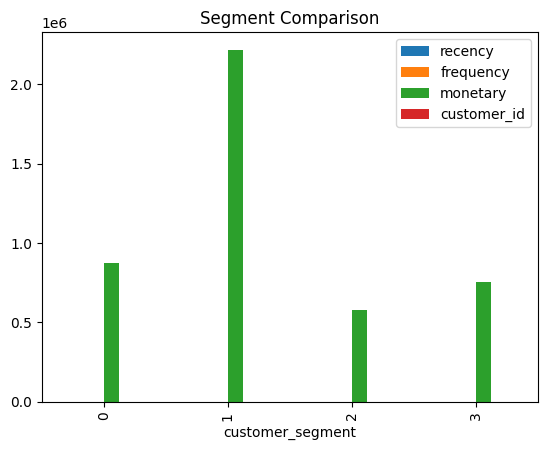

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google.colab import files
import os

# --- Re-calculating rfm_data and segment_summary to ensure availability ---
file_name = 'cleaned_ecommerce_data_2026.csv'

if not os.path.exists(file_name):
    print(f"The file '{file_name}' was not found. Please upload it.")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(f"'{file_name}' not uploaded. Please ensure you upload the correct file.")
    print(f"'{file_name}' uploaded successfully.")

df = pd.read_csv(file_name)
df['order_date'] = pd.to_datetime(df['order_date'])
current_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm_data = df.groupby('customer_id').agg({
    'order_date': lambda date: (current_date - date.max()).days,
    'order_id': 'count',
    'total_amount': 'sum'
}).reset_index()
rfm_data.columns = ['customer_id', 'recency', 'frequency', 'monetary']

scaler = StandardScaler()
columns_to_scale = ['recency', 'frequency', 'monetary']
scaled_numbers = scaler.fit_transform(rfm_data[columns_to_scale])

kmeans_model = KMeans(n_clusters=4, random_state=42)
rfm_data['customer_segment'] = kmeans_model.fit_predict(scaled_numbers)

segment_summary = rfm_data.groupby('customer_segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_id': 'count'
}).round(1)
# ----------------------------------------------------------------------

segment_summary.plot(kind='bar')
plt.title("Segment Comparison")
plt.savefig('segment_comparison_bar.png')
plt.show()

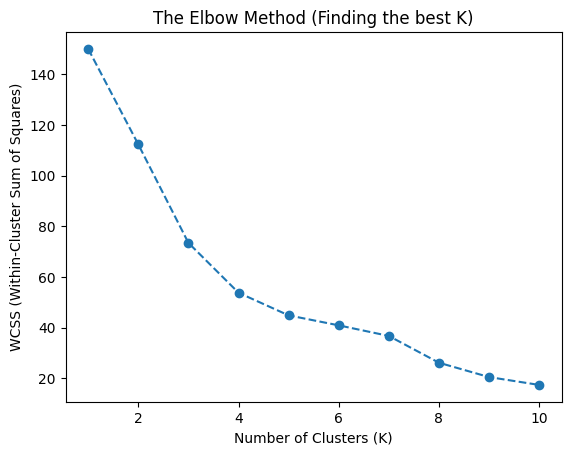

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from google.colab import files # Import files for upload functionality
import os # Import os to check for file existence

# --- Re-calculating rfm_data to ensure availability ---
file_name = 'cleaned_ecommerce_data_2026.csv'

if not os.path.exists(file_name):
    print(f"The file '{file_name}' was not found. Please upload it.")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(f"'{file_name}' not uploaded. Please ensure you upload the correct file.")
    print(f"'{file_name}' uploaded successfully.")

df = pd.read_csv(file_name)
df['order_date'] = pd.to_datetime(df['order_date'])
current_date = df['order_date'].max() + pd.Timedelta(days=1)
rfm_data = df.groupby('customer_id').agg({
    'order_date': lambda date: (current_date - date.max()).days,
    'order_id': 'count',
    'total_amount': 'sum'
}).reset_index()
rfm_data.columns = ['customer_id', 'recency', 'frequency', 'monetary']
# ------------------------------------------------------

# Scale the data
scaler = StandardScaler()
columns_to_scale = ['recency', 'frequency', 'monetary']
scaled_numbers = scaler.fit_transform(rfm_data[columns_to_scale])

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_numbers)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method (Finding the best K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.savefig('elbow_method_chart.png')
plt.show()

/tmp/ipykernel_448/1800473415.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='customer_segment', data=rfm_data, palette='viridis')


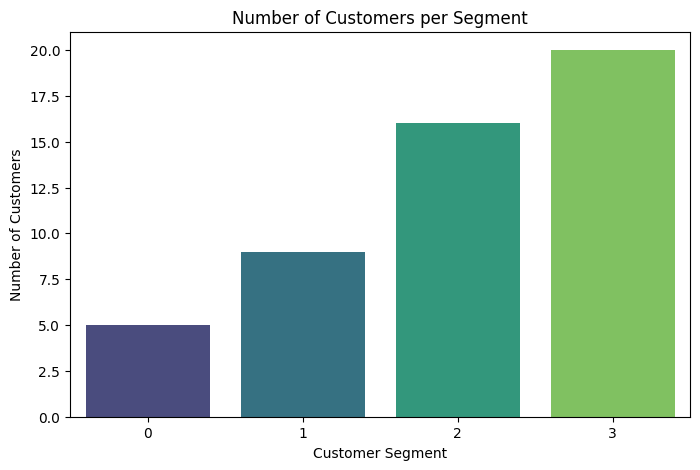

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google.colab import files
import os

file_name = 'cleaned_ecommerce_data_2026.csv'

if not os.path.exists(file_name):
    print(f"The file '{file_name}' was not found. Please upload it.")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(f"'{file_name}' not uploaded. Please ensure you upload the correct file.")
    print(f"'{file_name}' uploaded successfully.")

df = pd.read_csv(file_name)
df['order_date'] = pd.to_datetime(df['order_date'])
current_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm_data = df.groupby('customer_id').agg({
    'order_date': lambda date: (current_date - date.max()).days,
    'order_id': 'count',
    'total_amount': 'sum'
}).reset_index()
rfm_data.columns = ['customer_id', 'recency', 'frequency', 'monetary']

scaler = StandardScaler()
columns_to_scale = ['recency', 'frequency', 'monetary']
scaled_numbers = scaler.fit_transform(rfm_data[columns_to_scale])

kmeans_model = KMeans(n_clusters=4, random_state=42)
rfm_data['customer_segment'] = kmeans_model.fit_predict(scaled_numbers)

plt.figure(figsize=(8, 5))
sns.countplot(x='customer_segment', data=rfm_data, palette='viridis')
plt.title('Number of Customers per Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.savefig('customers_per_segment_count.png')
plt.show()

/tmp/ipykernel_448/2438955264.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='customer_segment', y='recency', data=rfm_data, palette='viridis')
/tmp/ipykernel_448/2438955264.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='customer_segment', y='frequency', data=rfm_data, palette='viridis')
/tmp/ipykernel_448/2438955264.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x='customer_segment', y='monetary', data=rfm_data, palette='viridis')


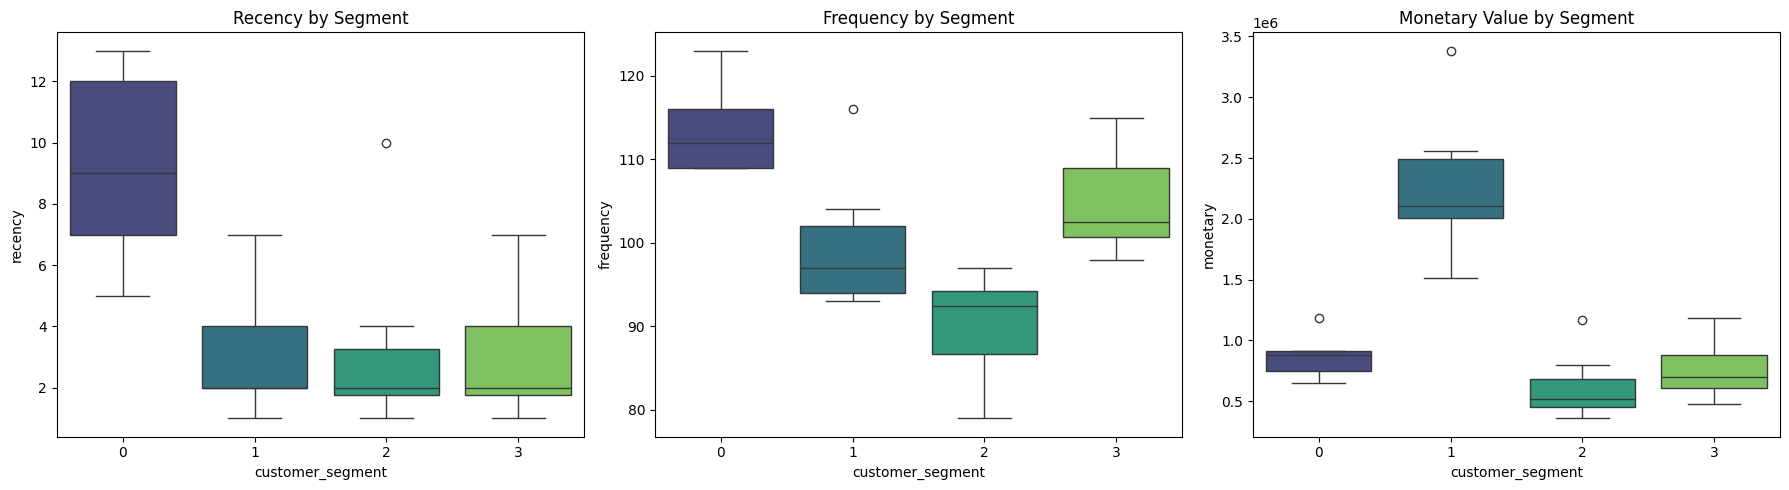

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], x='customer_segment', y='recency', data=rfm_data, palette='viridis')
axes[0].set_title('Recency by Segment')

sns.boxplot(ax=axes[1], x='customer_segment', y='frequency', data=rfm_data, palette='viridis')
axes[1].set_title('Frequency by Segment')

sns.boxplot(ax=axes[2], x='customer_segment', y='monetary', data=rfm_data, palette='viridis')
axes[2].set_title('Monetary Value by Segment')

plt.tight_layout()
plt.savefig('rfm_by_segment_boxplots.png')
plt.show()

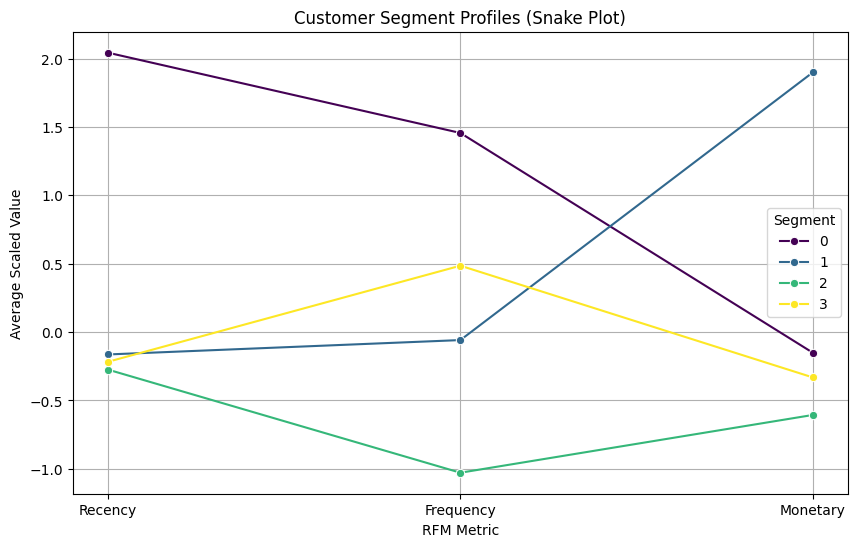

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Put scaled numbers back into a DataFrame so we can plot them
scaled_df = pd.DataFrame(scaled_numbers, columns=['Recency', 'Frequency', 'Monetary'])
scaled_df['Segment'] = rfm_data['customer_segment']

# Calculate the average (mean) of the scaled data for each segment
segment_means = scaled_df.groupby('Segment').mean().reset_index()

# Reshape the data for a line plot
melted_df = pd.melt(segment_means, id_vars=['Segment'], var_name='Metric', value_name='Average_Scaled_Value')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Metric', y='Average_Scaled_Value', hue='Segment', data=melted_df, marker='o', palette='viridis')
plt.title('Customer Segment Profiles (Snake Plot)')
plt.xlabel('RFM Metric')
plt.ylabel('Average Scaled Value')
plt.grid(True)
plt.savefig('snake_plot.png')
plt.show()

In [ ]:
#second problem that right now solving

In [ ]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# ==========================================
# STEP 2: LOAD THE DATA
# ==========================================
# Load your dataset
df = pd.read_csv('cleaned_ecommerce_data_2026.csv')

# ==========================================
# STEP 3: CREATE THE USER-ITEM MATRIX (The Pivot Table)
# ==========================================
# We need to build a table where:
# Rows = Products
# Columns = Customer IDs
# Values = How many of that product the customer bought (Quantity)

product_matrix = df.pivot_table(
    index='product_name',
    columns='customer_id',
    values='quantity',
    aggfunc='sum'
).fillna(0) # If a customer didn't buy a product, fill the blank with 0

print("--- Step 3 Completed: Matrix Created ---")
print(f"Matrix Shape: {product_matrix.shape[0]} Products by {product_matrix.shape[1]} Customers")


# ==========================================
# STEP 4: TRAIN THE KNN MODEL
# ==========================================
# We use 'cosine' distance. It measures the angle between two products to see if
# they are bought by the exact same group of people.
# n_neighbors=6 means it will find the product itself (1) + its 5 closest matches (5)
knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=6)

# Train the model on our product matrix
knn_model.fit(product_matrix)


# ==========================================
# STEP 5: CREATE THE RECOMMENDATION FUNCTION
# ==========================================
def get_recommendations(target_product):
    print(f"\n🔍 Finding recommendations for: '{target_product}'...\n")

    # 1. Find the exact row data for the requested product
    product_data = product_matrix.loc[target_product].values.reshape(1, -1)

    # 2. Ask the KNN model to find the nearest neighbors
    distances, indices = knn_model.kneighbors(product_data)

    # 3. Print the top 5 recommended products
    print("🛒 Customers who bought this also bought:")

    # We start the loop at 1 (instead of 0) because the 0th match is always the product itself!
    for i in range(1, len(distances.flatten())):
        recommended_item = product_matrix.index[indices.flatten()[i]]
        match_score = 1 - distances.flatten()[i] # Convert distance to a "Match Percentage"

        print(f"{i}. {recommended_item} (Match Score: {match_score:.2f})")

# ==========================================
# STEP 6: TEST THE ENGINE!
# ==========================================
# Let's test it by passing a product from your dataset (e.g., 'Laptop' or 'Webcam')
# Make sure the spelling perfectly matches a product in your dataset!

get_recommendations('Laptop')

--- Step 3 Completed: Matrix Created ---
Matrix Shape: 56 Products by 50 Customers

🔍 Finding recommendations for: 'Laptop'...

🛒 Customers who bought this also bought:
1. USB Hub (Match Score: 0.65)
2. Blazer (Match Score: 0.64)
3. Gym Gloves (Match Score: 0.61)
4. Self Help Book (Match Score: 0.56)
5. Yoga Mat (Match Score: 0.54)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


/tmp/ipykernel_448/2075062760.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='mako')


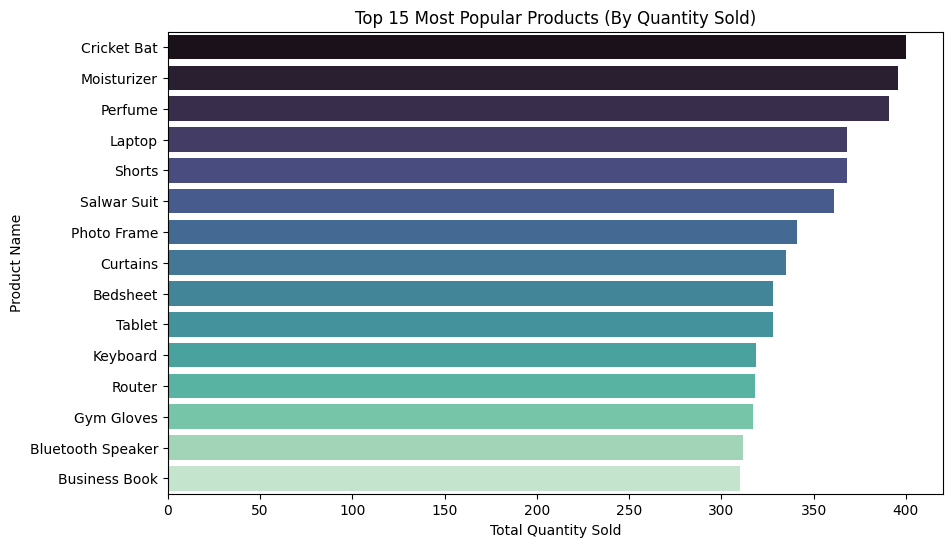

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total quantity sold for each product
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='mako')
plt.title("Top 15 Most Popular Products (By Quantity Sold)")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Name")
plt.savefig('top_products.png')
plt.show()

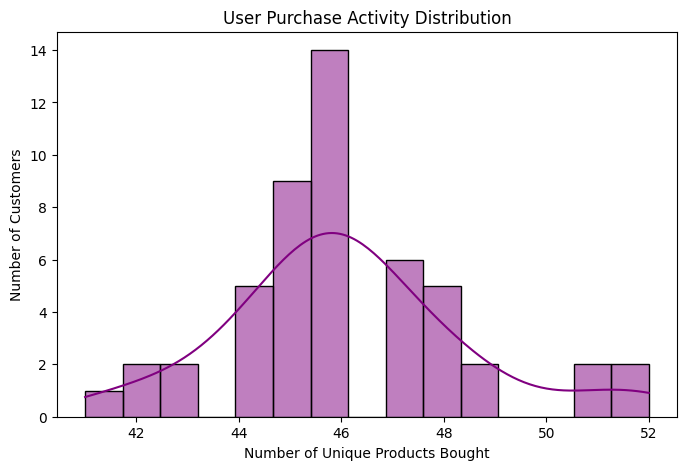

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many unique products each customer bought
user_activity = df.groupby('customer_id')['product_name'].nunique()

plt.figure(figsize=(8, 5))
sns.histplot(user_activity, bins=15, kde=True, color='purple')
plt.title("User Purchase Activity Distribution")
plt.xlabel("Number of Unique Products Bought")
plt.ylabel("Number of Customers")
plt.savefig('user_activity_distribution.png')
plt.show()

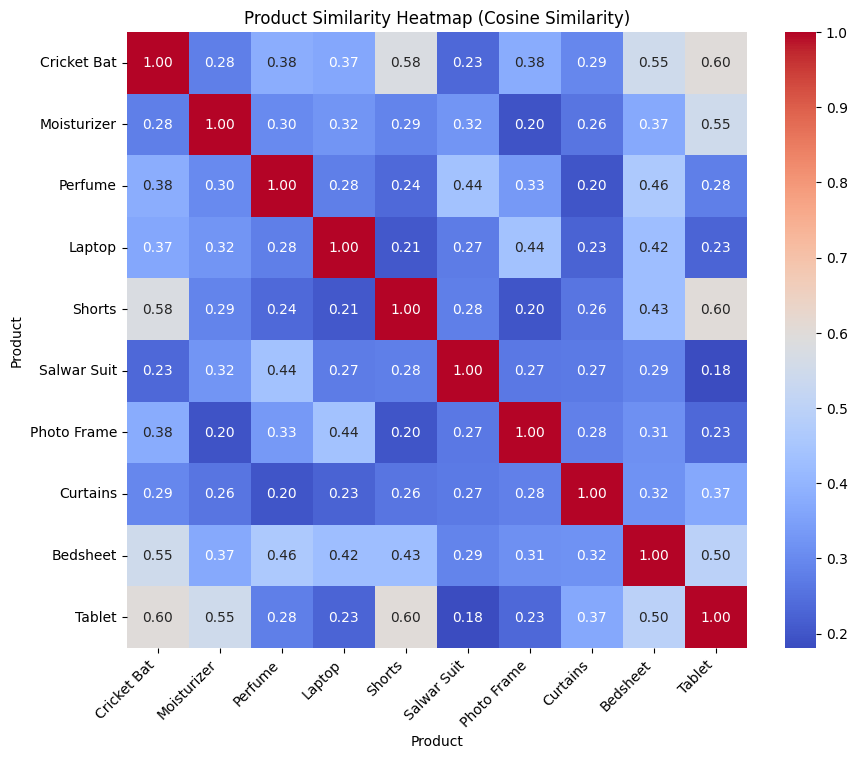

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Get the top 10 products to keep the heatmap clean and readable
top_10_items = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10).index
subset_matrix = product_matrix.loc[top_10_items]

# Calculate Cosine Similarity (This is what KNN calculates in the background)
similarity_matrix = cosine_similarity(subset_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, xticklabels=top_10_items, yticklabels=top_10_items,
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Product Similarity Heatmap (Cosine Similarity)")
plt.xlabel("Product")
plt.ylabel("Product")
plt.xticks(rotation=45, ha='right')
plt.savefig('product_similarity_heatmap.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/tmp/ipykernel_448/2810574661.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=match_scores, y=rec_names, palette='YlGnBu_r')


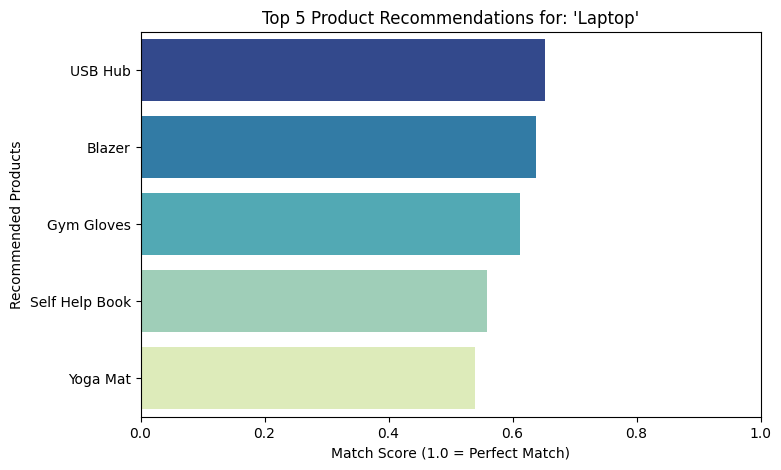

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# We will visualize the recommendations for 'Laptop'
target_product = 'Laptop'
product_data = product_matrix.loc[target_product].values.reshape(1, -1)

# Get distances and indices from your already trained KNN model
distances, indices = knn_model.kneighbors(product_data)

# Extract recommended product names and convert distances to Match Scores (1 - distance)
rec_names = [product_matrix.index[i] for i in indices.flatten()[1:]]
match_scores = [1 - d for d in distances.flatten()[1:]]

plt.figure(figsize=(8, 5))
sns.barplot(x=match_scores, y=rec_names, palette='YlGnBu_r')
plt.title(f"Top 5 Product Recommendations for: '{target_product}'")
plt.xlabel("Match Score (1.0 = Perfect Match)")
plt.ylabel("Recommended Products")
plt.xlim(0, 1.0)
plt.savefig('recommendation_barplot.png')
plt.show()

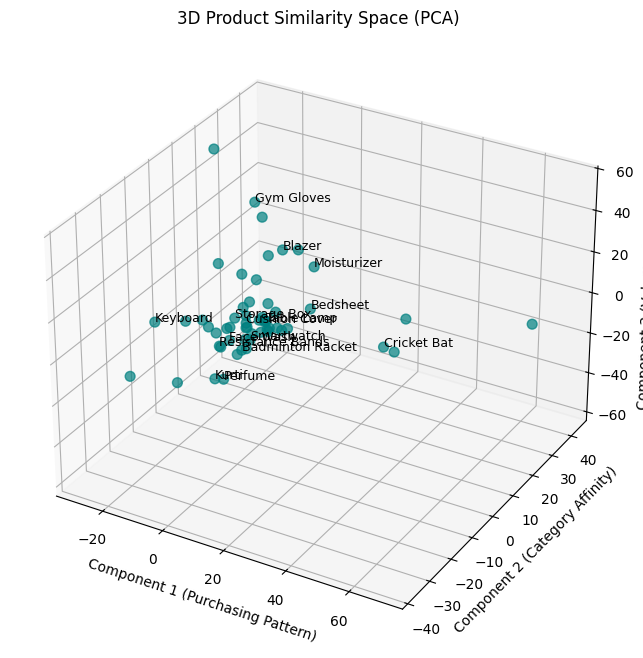

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# 1. We use PCA to reduce the hundreds of customer columns down to just 3 dimensions (X, Y, Z)
pca = PCA(n_components=3)
product_3d_coords = pca.fit_transform(product_matrix)

# 2. Extract X, Y, and Z coordinates for the plot
x_coords = product_3d_coords[:, 0]
y_coords = product_3d_coords[:, 1]
z_coords = product_3d_coords[:, 2]

# 3. Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter the products in 3D space
ax.scatter(x_coords, y_coords, z_coords, c='teal', s=50, alpha=0.7)

# Add text labels to a few of the top products so the plot isn't too messy
top_products = df['product_name'].value_counts().head(15).index
for i, product_name in enumerate(product_matrix.index):
    if product_name in top_products:
        ax.text(x_coords[i], y_coords[i], z_coords[i], product_name, fontsize=9)

ax.set_title('3D Product Similarity Space (PCA)')
ax.set_xlabel('Component 1 (Purchasing Pattern)')
ax.set_ylabel('Component 2 (Category Affinity)')
ax.set_zlabel('Component 3 (Volume Correlation)')
plt.savefig('product_3d_pca.png')
plt.show()

In [ ]:
from google.colab import files

# List of chart files from Problem 2 to download
chart_files_problem2 = [
    'top_products.png',
    'user_activity_distribution.png',
    'product_similarity_heatmap.png',
    'recommendation_barplot.png',
    'product_3d_pca.png'
]

print("Downloading generated chart files from Problem 2...")
for chart_file in chart_files_problem2:
    try:
        files.download(chart_file)
        print(f"Successfully downloaded: {chart_file}")
    except FileNotFoundError:
        print(f"Warning: {chart_file} not found. It might not have been generated or the name is incorrect.")

print("Download process for Problem 2 complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: top_products.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Successfully downloaded: recommendation_barplot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: product_3d_pca.png
Download process for Problem 2 complete.


In [ ]:
from google.colab import files

# List of chart files from Problem 2 to download
chart_files_problem2 = [
    'top_products.png',
    'user_activity_distribution.png',
    'product_similarity_heatmap.png',
    'recommendation_barplot.png',
    'product_3d_pca.png'
]

print("Downloading generated chart files from Problem 2...")
for chart_file in chart_files_problem2:
    try:
        files.download(chart_file)
        print(f"Successfully downloaded: {chart_file}")
    except FileNotFoundError:
        print(f"Warning: {chart_file} not found. It might not have been generated or the name is incorrect.")

print("Download process for Problem 2 complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: top_products.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Successfully downloaded: recommendation_barplot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: product_3d_pca.png
Download process for Problem 2 complete.


In [ ]:
from google.colab import files

# List of all chart files to download
chart_files = [
    'monetary_distribution.png',
    'frequency_distribution.png',
    'rfm_scatter_segments.png',
    'rfm_3d_scatter.png',
    'segment_comparison_bar.png',
    'elbow_method_chart.png',
    'customers_per_segment_count.png',
    'rfm_by_segment_boxplots.png',
    'snake_plot.png'
]

print("Downloading generated chart files...")
for chart_file in chart_files:
    try:
        files.download(chart_file)
        print(f"Successfully downloaded: {chart_file}")
    except FileNotFoundError:
        print(f"Warning: {chart_file} not found. It might not have been generated or the name is incorrect.")

print("Download process complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: monetary_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Successfully downloaded: rfm_by_segment_boxplots.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: snake_plot.png
Download process complete.


In [ ]:
from google.colab import files

# List of all chart files to download
chart_files = [
    'monetary_distribution.png',
    'frequency_distribution.png',
    'rfm_scatter_segments.png',
    'rfm_3d_scatter.png',
    'segment_comparison_bar.png',
    'elbow_method_chart.png',
    'customers_per_segment_count.png',
    'rfm_by_segment_boxplots.png',
    'snake_plot.png'
]

print("Downloading generated chart files...")
for chart_file in chart_files:
    try:
        files.download(chart_file)
        print(f"Successfully downloaded: {chart_file}")
    except FileNotFoundError:
        print(f"Warning: {chart_file} not found. It might not have been generated or the name is incorrect.")

print("Download process complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: monetary_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Successfully downloaded: rfm_by_segment_boxplots.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: snake_plot.png
Download process complete.


In [ ]:
from google.colab import files

# List of all chart files to download
chart_files = [
    'monetary_distribution.png',
    'frequency_distribution.png',
    'rfm_scatter_segments.png',
    'rfm_3d_scatter.png',
    'segment_comparison_bar.png',
    'elbow_method_chart.png',
    'customers_per_segment_count.png',
    'rfm_by_segment_boxplots.png',
    'snake_plot.png'
]

print("Downloading generated chart files...")
for chart_file in chart_files:
    try:
        files.download(chart_file)
        print(f"Successfully downloaded: {chart_file}")
    except FileNotFoundError:
        print(f"Warning: {chart_file} not found. It might not have been generated or the name is incorrect.")

print("Download process complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: monetary_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Successfully downloaded: rfm_by_segment_boxplots.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: snake_plot.png
Download process complete.
